In [ ]:
#Tabular / Simple Counting Probability way , doesn't work for cases when we wanna know what comes after two or more characters because tabulating becomes infeasible

In [2]:
from easyocr.config import latin_lang_list
from sklearn.covariance import log_likelihood

words = open('names.txt','r').read().splitlines()

In [3]:
max(len(word) for word in words)

15

In [4]:
b = dict()
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1,ch2 in zip(chs,chs[1:]):
        bigram = (ch1,ch2)
        b[bigram]=b.get(bigram,0)+1

In [5]:
sorted(b.items(),key= lambda kv: -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [6]:
import torch

In [7]:
N = torch.zeros((27,27),dtype=torch.int32)

In [8]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.']=0

In [9]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        N[ix1,ix2]+=1


In [10]:
import matplotlib.pyplot as plt
%matplotlib inline

In [11]:
itos = {i:s for s,i in stoi.items()}

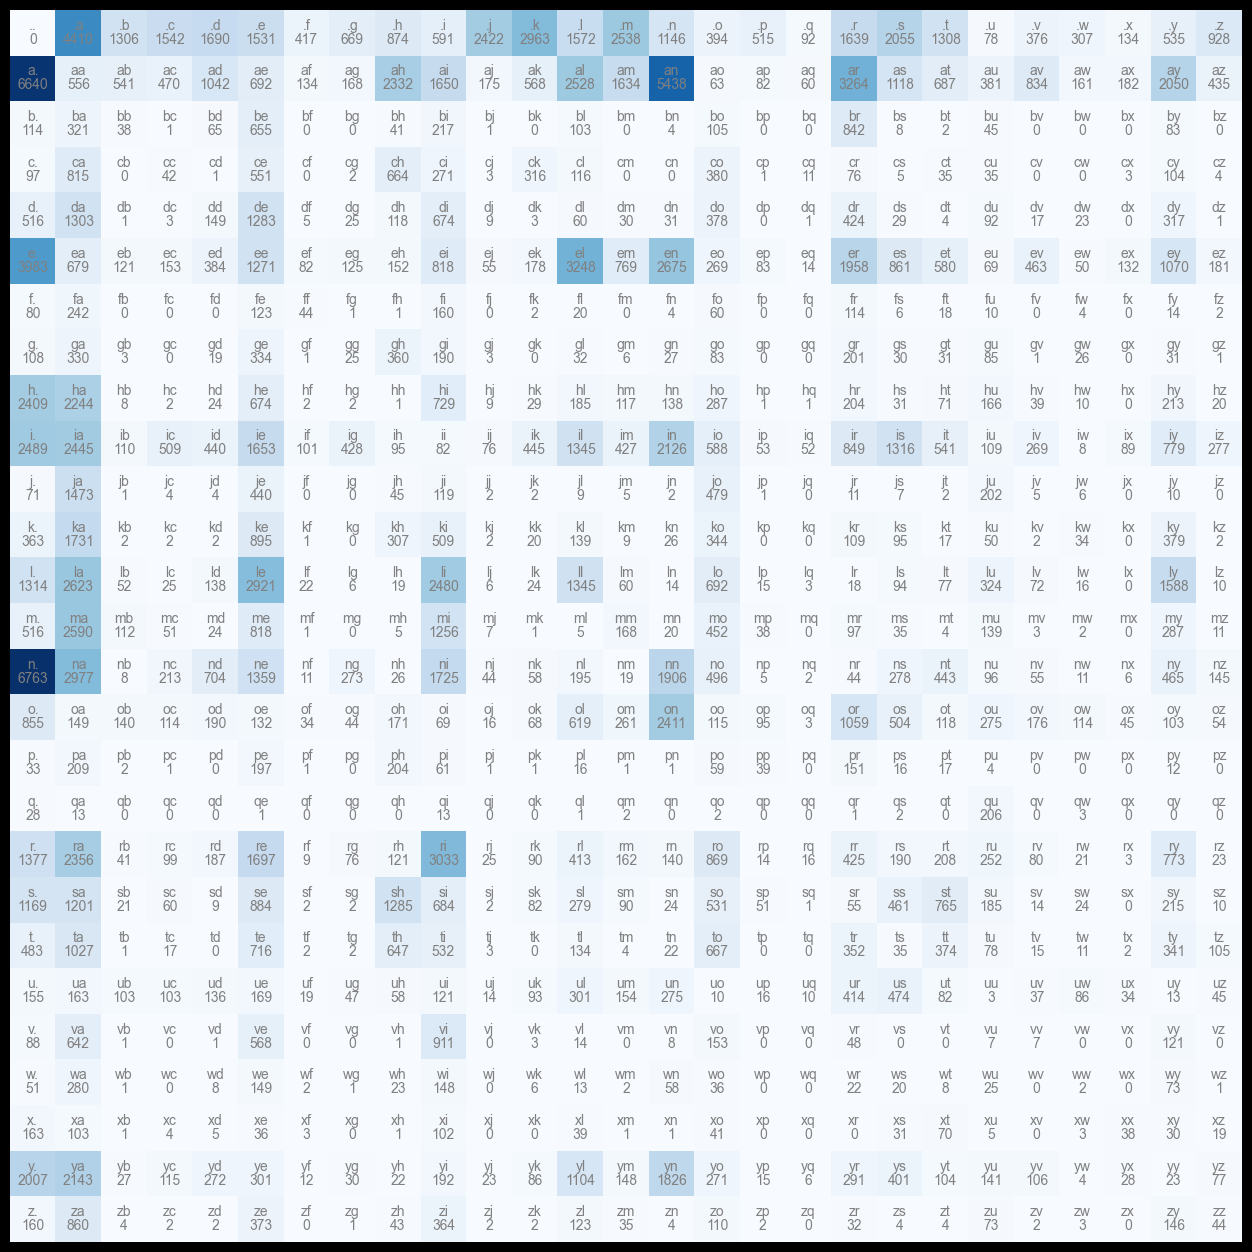

In [12]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');


In [13]:
P = (N+1).float()
P /= P.sum(dim=1,keepdim=True)

In [14]:
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
    out=[]
    ix = 0
    while True:
        p=P[ix]
        ix=torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
        out.append(itos[ix])
        if ix==0:
            break
    print("".join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


In [15]:
n = 0
log_likelihood = 0.0
for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob=P[ix1,ix2]
        n+=1
        logprob = torch.log(prob)
        log_likelihood+=logprob
        print(f'{ch1}{ch2} : {prob}')
ll = log_likelihood/n
nl = -ll
nl

.e : 0.0477868914604187
em : 0.03765281289815903
mm : 0.025341130793094635
ma : 0.3885140120983124
a. : 0.19583038985729218
.o : 0.012321033515036106
ol : 0.0778796598315239
li : 0.17740435898303986
iv : 0.015230144374072552
vi : 0.3507692217826843
ia : 0.1379738301038742
a. : 0.19583038985729218
.a : 0.13759006559848785
av : 0.02462255209684372
va : 0.247307687997818
a. : 0.19583038985729218


tensor(2.4255)

In [ ]:
#Single neuron way

In [16]:
xs,ys = [],[]

for w in words:
    chs = ['.']+list(w)+['.']
    for ch1,ch2 in zip(chs,chs[1::]):
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
x = len(xs)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
x

228140

In [17]:
xs

tensor([ 0,  5, 13,  ..., 18, 15, 14])

In [18]:
ys

tensor([ 5, 13, 13,  ..., 15, 14,  0])

In [19]:
import torch.nn.functional as F

In [20]:
'''nlls = torch.zeros(5)
for i in range(5):
    x=xs[i].item()
    y=ys[i].item()
    print('-------------------')
    print(f'Bigram Example {i+1}: Bigram = {itos[x]}{itos[y]} (at Index {x},{y})')
    print(f'Input to the neural net: {x}')
    print(f'Output Probabilities from the neural net : {probs[i]}')
    print(f'label (Actual Next Character: {y}')
    p = probs[i,y]
    print(f'Probabilty assigned to the next character: {p.item()}')
    logp = torch.log(p)
    print('Log_likelihood: ',logp)
    nll = -logp
    print('Negative Log_likelihood: ',nll.item())
    nlls[i]=nll
print("=====================")
print('Average negative log_likelihood (i.e., Loss)',nlls.mean().item())'''


'nlls = torch.zeros(5)\nfor i in range(5):\n    x=xs[i].item()\n    y=ys[i].item()\n    print(\'-------------------\')\n    print(f\'Bigram Example {i+1}: Bigram = {itos[x]}{itos[y]} (at Index {x},{y})\')\n    print(f\'Input to the neural net: {x}\')\n    print(f\'Output Probabilities from the neural net : {probs[i]}\')\n    print(f\'label (Actual Next Character: {y}\')\n    p = probs[i,y]\n    print(f\'Probabilty assigned to the next character: {p.item()}\')\n    logp = torch.log(p)\n    print(\'Log_likelihood: \',logp)\n    nll = -logp\n    print(\'Negative Log_likelihood: \',nll.item())\n    nlls[i]=nll\nprint("=====================")\nprint(\'Average negative log_likelihood (i.e., Loss)\',nlls.mean().item())'

In [21]:
g = torch.Generator().manual_seed(2147483647)
W=torch.randn((27,27),generator=g,requires_grad=True)

In [22]:
for k in range(100):
    #forward pass
    xenc=F.one_hot(xs,num_classes=27).float()
    logits=xenc@W #log counts
    counts=logits.exp() #counts equivalent N
    probs = counts/counts.sum(1,keepdim=True)
    loss = -probs[torch.arange(x),ys].log().mean()
    print(loss.item())
    #backward pass
    W.grad=None
    loss.backward()
    W.data+=-50*W.grad

3.758967399597168
3.3710954189300537
3.1540298461914062
3.0203564167022705
2.9276912212371826
2.8603808879852295
2.809706211090088
2.770078659057617
2.738048553466797
2.7114710807800293
2.688977003097534
2.6696619987487793
2.6529030799865723
2.6382498741149902
2.6253604888916016
2.6139628887176514
2.603835105895996
2.5947935581207275
2.5866832733154297
2.5793755054473877
2.572760581970215
2.5667476654052734
2.5612592697143555
2.556230306625366
2.551604747772217
2.547337532043457
2.543386936187744
2.539720058441162
2.5363080501556396
2.53312611579895
2.5301520824432373
2.5273680686950684
2.5247578620910645
2.522306203842163
2.520000696182251
2.517829418182373
2.515782356262207
2.513849973678589
2.512023687362671
2.5102953910827637
2.5086586475372314
2.507106304168701
2.5056331157684326
2.5042331218719482
2.5029008388519287
2.5016324520111084
2.5004239082336426
2.499270439147949
2.498169183731079
2.4971165657043457
2.4961094856262207
2.495145320892334
2.4942212104797363
2.493334770202636

In [23]:
logits.shape

torch.Size([228140, 27])